In [3]:
# Bibliotecas que vamos usar no projeto
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer

# Carrega a base de câncer de mama (já vem dentro do scikit-learn)
dados = load_breast_cancer()

# Monta uma tabela com as 30 medidas + a coluna de diagnóstico
df = pd.DataFrame(dados.data, columns=dados.feature_names)
df['diagnostico'] = dados.target   # 0 = maligno, 1 = benigno

# Mostra o tamanho da tabela e as primeiras linhas
print("Formato (linhas, colunas):", df.shape)
df.head()

Formato (linhas, colunas): (569, 31)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
# Quantas pacientes de cada diagnóstico temos?
contagem = df['diagnostico'].value_counts().sort_index()
print("Contagem por diagnóstico:")
print(f"  Maligno (0): {contagem[0]} pacientes ({contagem[0]/len(df)*100:.1f}%)")
print(f"  Benigno (1): {contagem[1]} pacientes ({contagem[1]/len(df)*100:.1f}%)")
print()

# Tem algum valor faltando na base?
print("Valores faltando na base inteira:", df.isnull().sum().sum())

Contagem por diagnóstico:
  Maligno (0): 212 pacientes (37.3%)
  Benigno (1): 357 pacientes (62.7%)

Valores faltando na base inteira: 0


In [5]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnostico
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


In [6]:
# Médias de algumas medidas, separadas por tipo de diagnóstico
medidas = ['mean radius', 'mean perimeter', 'mean area',
           'mean concavity', 'mean concave points', 'worst area']

comparacao = df.groupby('diagnostico')[medidas].mean().T
comparacao.columns = ['Maligno (0)', 'Benigno (1)']
print(comparacao.round(2))

                     Maligno (0)  Benigno (1)
mean radius                17.46        12.15
mean perimeter            115.37        78.08
mean area                 978.38       462.79
mean concavity              0.16         0.05
mean concave points         0.09         0.03
worst area               1422.29       558.90


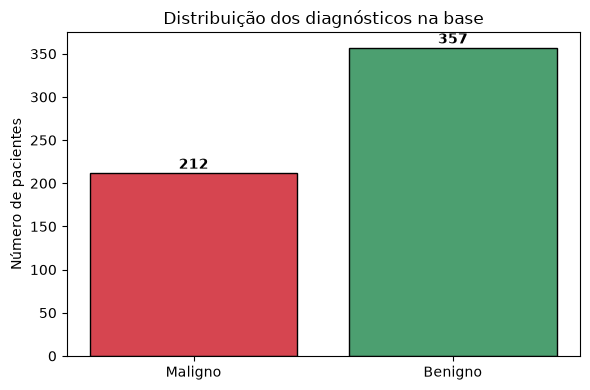

In [7]:
# Gráfico: distribuição dos diagnósticos
plt.figure(figsize=(6, 4))
cores = {0: '#d64550', 1: '#4c9f70'}
contagem = df['diagnostico'].value_counts().sort_index()
plt.bar(['Maligno', 'Benigno'], contagem.values, color=[cores[0], cores[1]], edgecolor='black')
plt.title('Distribuição dos diagnósticos na base')
plt.ylabel('Número de pacientes')
for i, v in enumerate(contagem.values):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

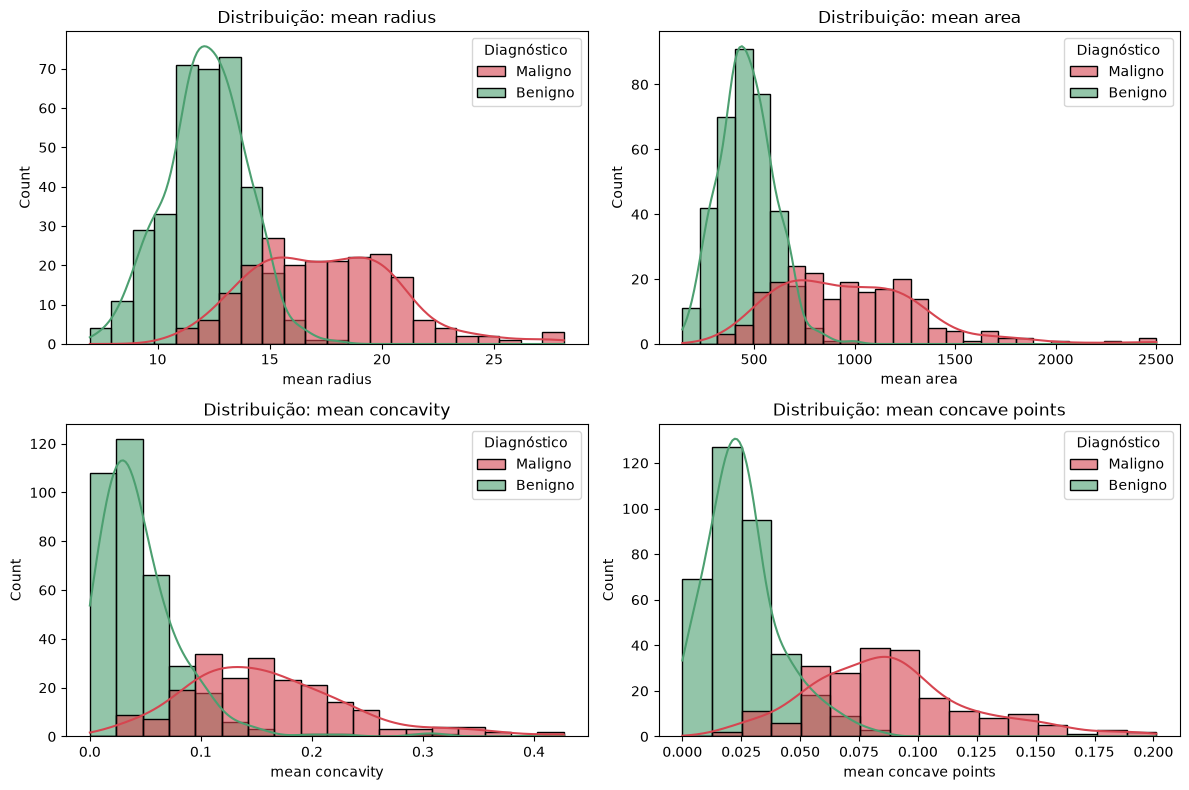

In [8]:
# Compara a distribuição de algumas medidas entre malignos e benignos
medidas_chave = ['mean radius', 'mean area', 'mean concavity', 'mean concave points']

# Cria uma versão com rótulos em texto pra ficar bonito na legenda
df_plot = df.copy()
df_plot['Diagnóstico'] = df_plot['diagnostico'].map({0: 'Maligno', 1: 'Benigno'})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, medida in zip(axes.flat, medidas_chave):
    sns.histplot(data=df_plot, x=medida, hue='Diagnóstico',
                 palette={'Maligno': '#d64550', 'Benigno': '#4c9f70'},
                 alpha=0.6, ax=ax, kde=True)
    ax.set_title(f'Distribuição: {medida}')

plt.tight_layout()
plt.show()


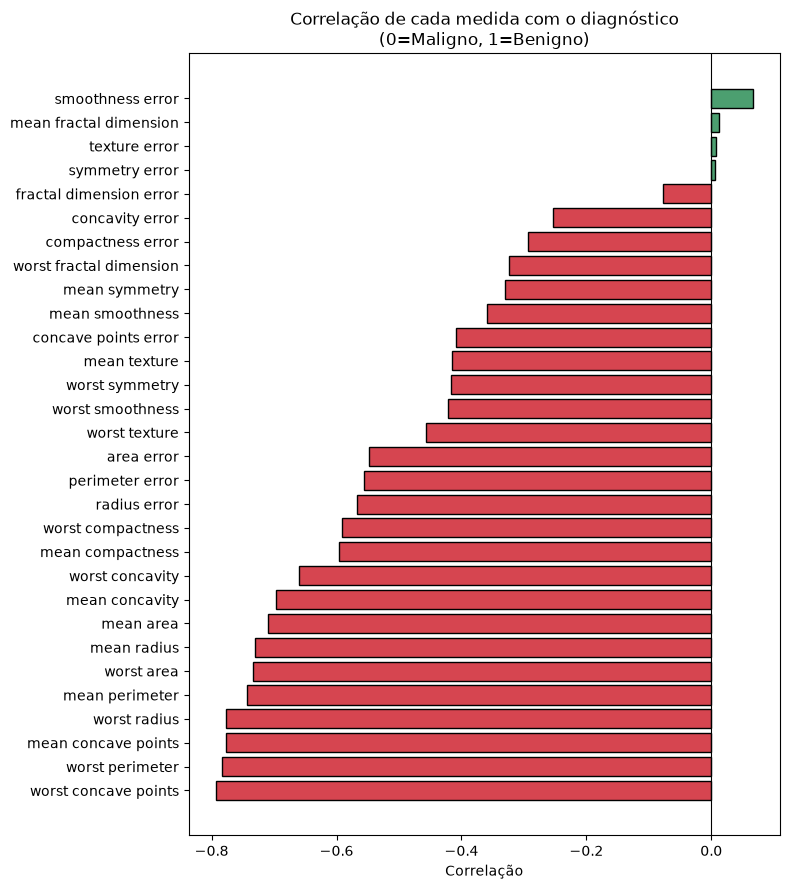

In [9]:
# Correlação de cada medida com o diagnóstico, da mais forte pra mais fraca
correlacoes = df.corr()['diagnostico'].drop('diagnostico').sort_values()

plt.figure(figsize=(8, 9))
cores_barras = ['#d64550' if c < 0 else '#4c9f70' for c in correlacoes.values]
plt.barh(correlacoes.index, correlacoes.values, color=cores_barras, edgecolor='black')
plt.title('Correlação de cada medida com o diagnóstico\n(0=Maligno, 1=Benigno)')
plt.xlabel('Correlação')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

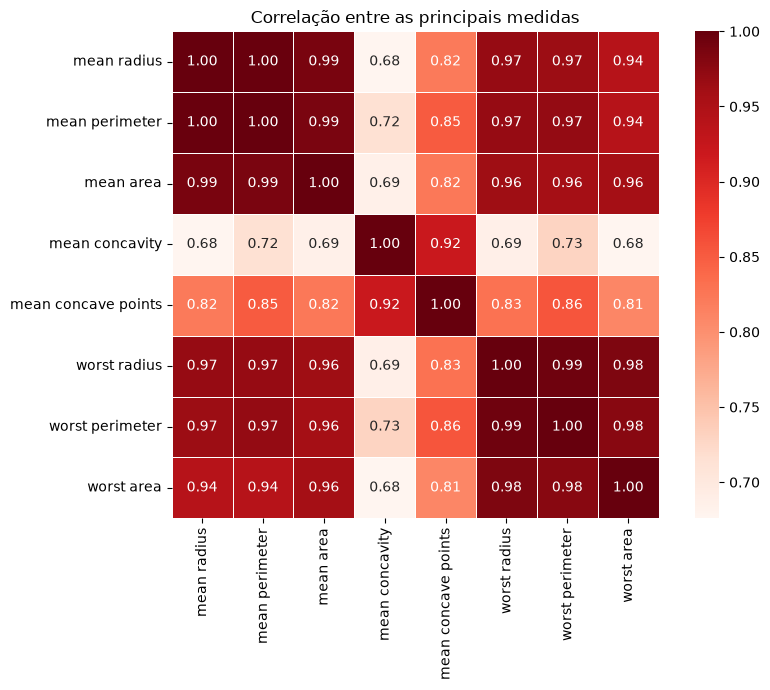

In [10]:
# Mapa de calor: o quanto algumas medidas "andam junto" umas com as outras
medidas_top = ['mean radius', 'mean perimeter', 'mean area',
               'mean concavity', 'mean concave points',
               'worst radius', 'worst perimeter', 'worst area']

plt.figure(figsize=(9, 7))
sns.heatmap(df[medidas_top].corr(), annot=True, cmap='Reds',
            fmt='.2f', linewidths=0.5, square=True)
plt.title('Correlação entre as principais medidas')
plt.tight_layout()
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

# Passo 1: separar as medidas (X) do diagnóstico (y)
X = df.drop('diagnostico', axis=1)   # todas as 30 medidas
y = df['diagnostico']                # a resposta (0=maligno, 1=benigno)

# Passo 2: dividir em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,        # 20% das pacientes ficam separadas pro teste
    random_state=42,       # garante que a divisão seja sempre a mesma
    stratify=y             # mantém a proporção 37/63 nos dois grupos
)

print("Pacientes para TREINO:", X_train.shape[0])
print("Pacientes para TESTE: ", X_test.shape[0])
print()
print("Proporção maligno/benigno no treino:")
print(y_train.value_counts(normalize=True).round(3))

Pacientes para TREINO: 455
Pacientes para TESTE:  114

Proporção maligno/benigno no treino:
diagnostico
1    0.626
0    0.374
Name: proportion, dtype: float64


In [12]:
from sklearn.preprocessing import StandardScaler

# Cria o "padronizador"
scaler = StandardScaler()

# APRENDE a escala SÓ com o treino e já transforma o treino
X_train_scaled = scaler.fit_transform(X_train)

# APLICA a mesma escala no teste (sem reaprender — só transforma)
X_test_scaled = scaler.transform(X_test)

print("Padronização concluída.")
print()
print("Antes (treino original) — exemplo da coluna 'mean area':")
print(f"  média = {X_train['mean area'].mean():.1f}, valores indo de {X_train['mean area'].min():.0f} a {X_train['mean area'].max():.0f}")
print()
print("Depois (treino padronizado) — mesma coluna:")
import numpy as np
col_area = list(X.columns).index('mean area')
print(f"  média = {X_train_scaled[:, col_area].mean():.2f}, desvio padrão = {X_train_scaled[:, col_area].std():.2f}")

Padronização concluída.

Antes (treino original) — exemplo da coluna 'mean area':
  média = 648.5, valores indo de 144 a 2499

Depois (treino padronizado) — mesma coluna:
  média = -0.00, desvio padrão = 1.00


In [13]:
from sklearn.linear_model import LogisticRegression

# Cria o modelo
modelo_lr = LogisticRegression(max_iter=5000, random_state=42)

# TREINA: mostra ao modelo as medidas (X) e as respostas (y) do treino
modelo_lr.fit(X_train_scaled, y_train)

# PREVÊ: pede pro modelo adivinhar o diagnóstico das 114 pacientes do TESTE
#         (pacientes que ele NUNCA viu durante o treino)
y_pred_lr = modelo_lr.predict(X_test_scaled)

print("Modelo treinado e previsões feitas!")
print()
print("Exemplo — primeiras 10 pacientes do teste:")
print("Modelo previu:", list(y_pred_lr[:10]))
print("Era de verdade:", list(y_test[:10].values))

Modelo treinado e previsões feitas!

Exemplo — primeiras 10 pacientes do teste:
Modelo previu: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]
Era de verdade: [np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(0), np.int64(0)]


In [14]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# Avalia o modelo nas 114 pacientes do teste
acc = accuracy_score(y_test, y_pred_lr)
# IMPORTANTE: maligno é a classe 0, então pos_label=0 mede o desempenho NO CÂNCER
recall_maligno = recall_score(y_test, y_pred_lr, pos_label=0)
precision_maligno = precision_score(y_test, y_pred_lr, pos_label=0)
f1_maligno = f1_score(y_test, y_pred_lr, pos_label=0)

print("=== DESEMPENHO DA REGRESSÃO LOGÍSTICA ===")
print(f"Acurácia geral:            {acc*100:.1f}%")
print(f"Recall (no maligno):       {recall_maligno*100:.1f}%")
print(f"Precisão (no maligno):     {precision_maligno*100:.1f}%")
print(f"F1-score (no maligno):     {f1_maligno*100:.1f}%")

=== DESEMPENHO DA REGRESSÃO LOGÍSTICA ===
Acurácia geral:            98.2%
Recall (no maligno):       97.6%
Precisão (no maligno):     97.6%
F1-score (no maligno):     97.6%


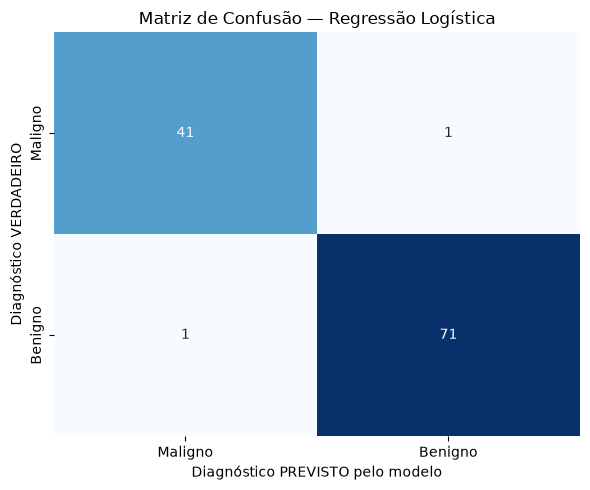

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Maligno', 'Benigno'],
            yticklabels=['Maligno', 'Benigno'])
plt.title('Matriz de Confusão — Regressão Logística')
plt.ylabel('Diagnóstico VERDADEIRO')
plt.xlabel('Diagnóstico PREVISTO pelo modelo')
plt.tight_layout()
plt.show()

In [16]:
from sklearn.tree import DecisionTreeClassifier

# Cria e treina a Árvore de Decisão
# max_depth=4 limita o tamanho da árvore pra ela não "decorar" o treino
modelo_arvore = DecisionTreeClassifier(max_depth=4, random_state=42)
modelo_arvore.fit(X_train, y_train)   # repara: árvore NÃO precisa de dados padronizados

# Prevê no teste
y_pred_arvore = modelo_arvore.predict(X_test)

# Avalia com as mesmas métricas, pra comparar de igual pra igual
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
print("=== DESEMPENHO DA ÁRVORE DE DECISÃO ===")
print(f"Acurácia geral:          {accuracy_score(y_test, y_pred_arvore)*100:.1f}%")
print(f"Recall (no maligno):     {recall_score(y_test, y_pred_arvore, pos_label=0)*100:.1f}%")
print(f"Precisão (no maligno):   {precision_score(y_test, y_pred_arvore, pos_label=0)*100:.1f}%")
print(f"F1-score (no maligno):   {f1_score(y_test, y_pred_arvore, pos_label=0)*100:.1f}%")

=== DESEMPENHO DA ÁRVORE DE DECISÃO ===
Acurácia geral:          93.9%
Recall (no maligno):     92.9%
Precisão (no maligno):   90.7%
F1-score (no maligno):   91.8%


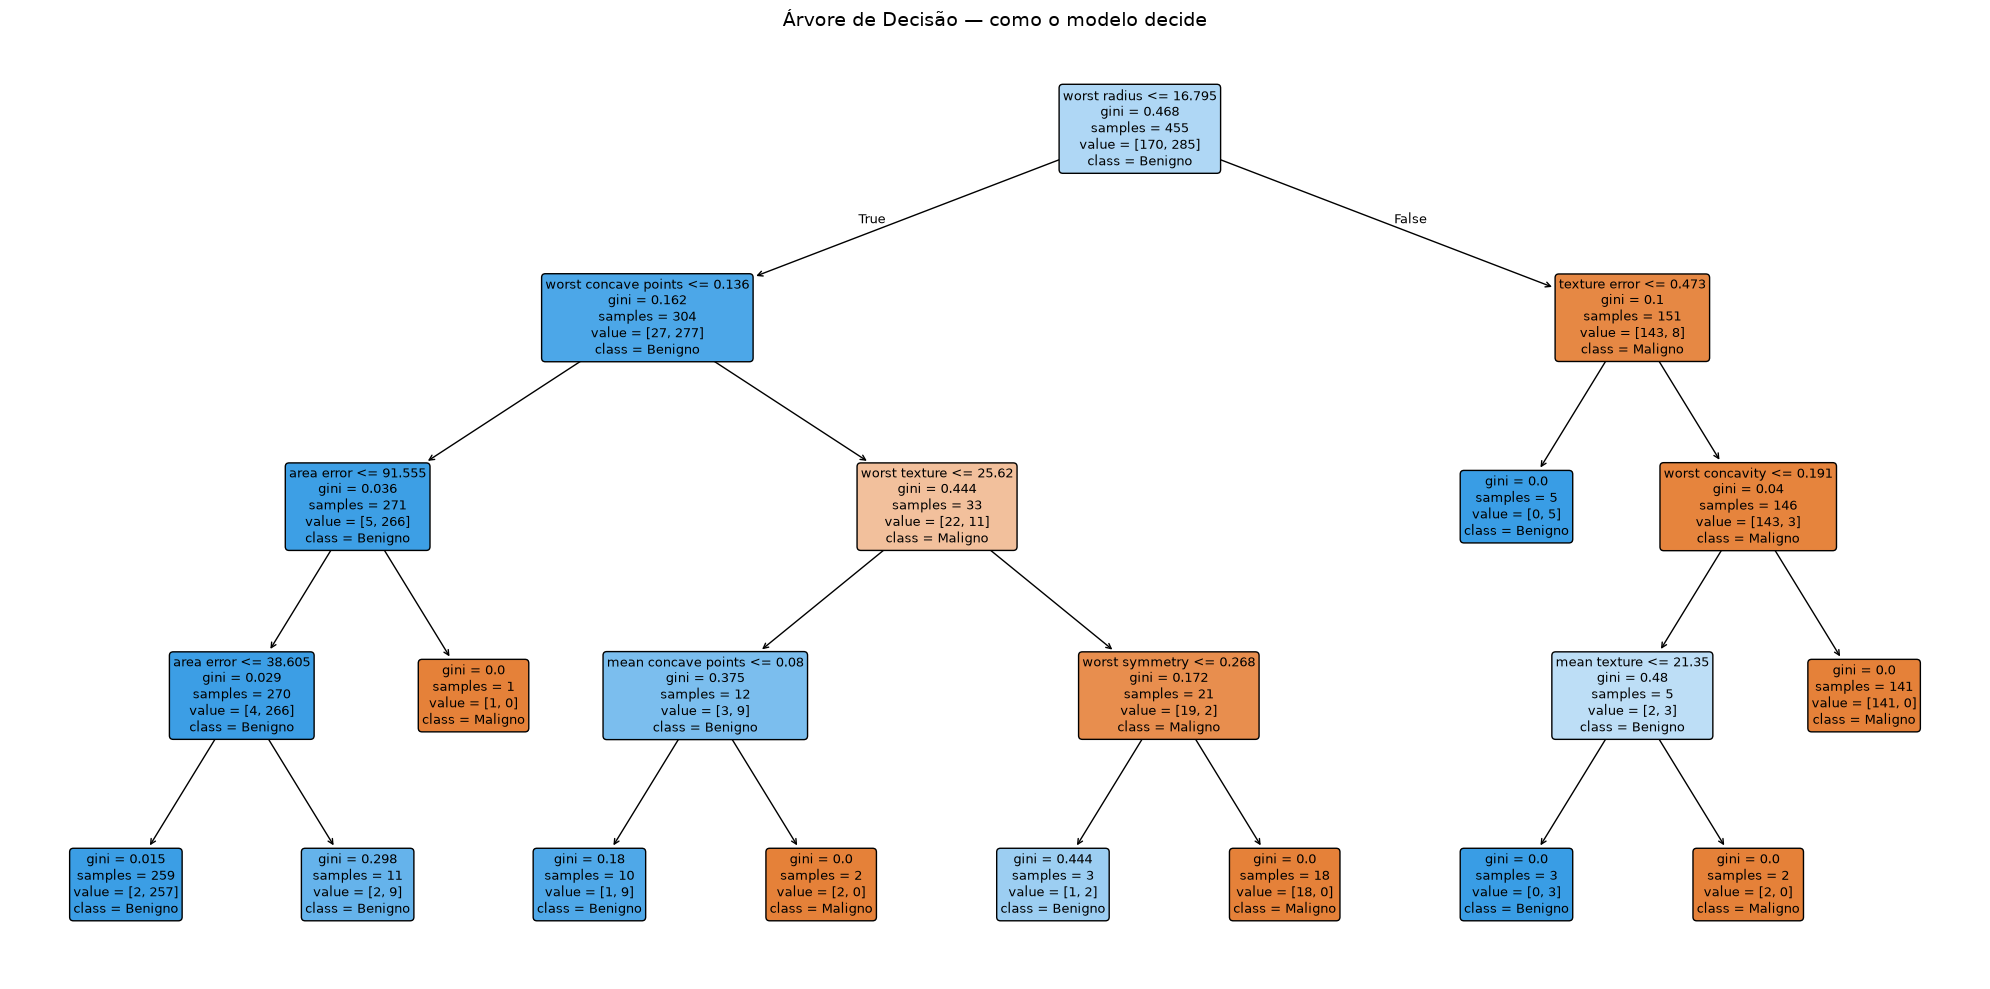

In [17]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))
plot_tree(modelo_arvore,
          feature_names=X.columns,
          class_names=['Maligno', 'Benigno'],
          filled=True, rounded=True, fontsize=9)
plt.title('Árvore de Decisão — como o modelo decide', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier

# Cria a floresta com 200 árvores
modelo_rf = RandomForestClassifier(n_estimators=200, random_state=42)
modelo_rf.fit(X_train, y_train)   # floresta também não precisa de padronização

# Prevê no teste
y_pred_rf = modelo_rf.predict(X_test)

# Avalia com as mesmas métricas de sempre
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
print("=== DESEMPENHO DO RANDOM FOREST ===")
print(f"Acurácia geral:          {accuracy_score(y_test, y_pred_rf)*100:.1f}%")
print(f"Recall (no maligno):     {recall_score(y_test, y_pred_rf, pos_label=0)*100:.1f}%")
print(f"Precisão (no maligno):   {precision_score(y_test, y_pred_rf, pos_label=0)*100:.1f}%")
print(f"F1-score (no maligno):   {f1_score(y_test, y_pred_rf, pos_label=0)*100:.1f}%")

=== DESEMPENHO DO RANDOM FOREST ===
Acurácia geral:          95.6%
Recall (no maligno):     92.9%
Precisão (no maligno):   95.1%
F1-score (no maligno):   94.0%


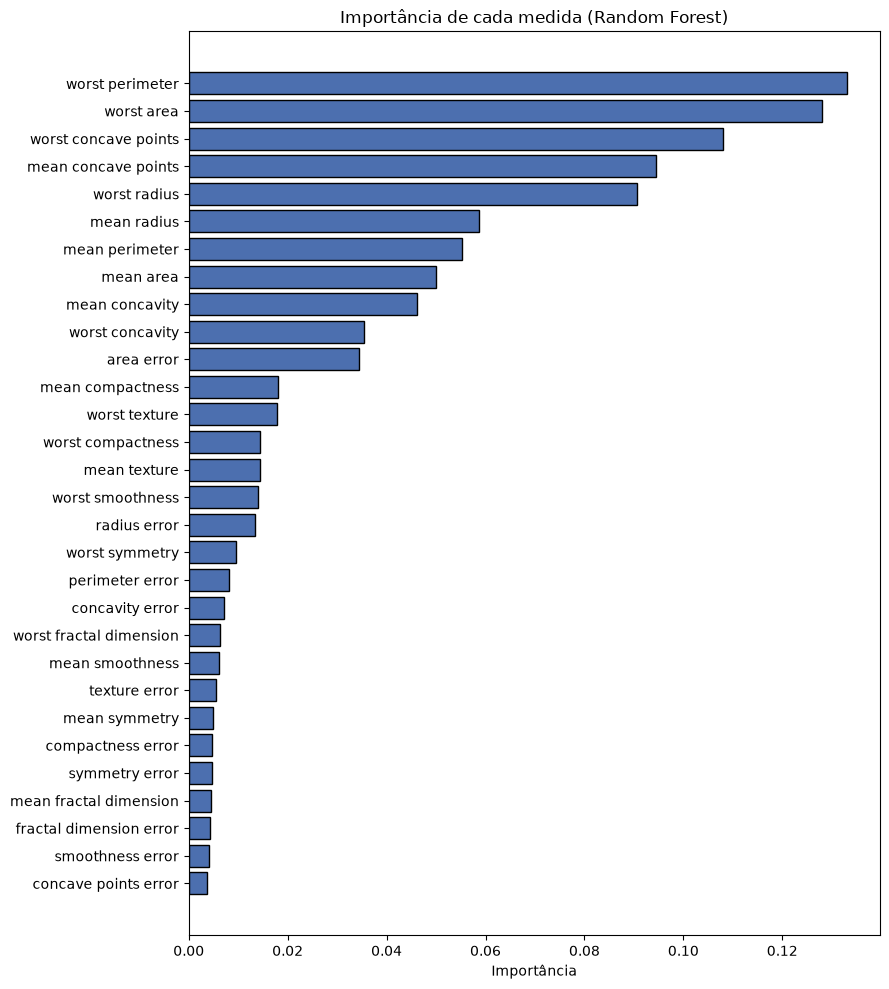

TOP 5 medidas mais importantes:
worst perimeter         0.133
worst area              0.128
worst concave points    0.108
mean concave points     0.094
worst radius            0.091
dtype: float64


In [19]:
import pandas as pd

# Pergunta ao Random Forest a importância de cada medida
importancias = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=True)

plt.figure(figsize=(9, 10))
plt.barh(importancias.index, importancias.values, color='#4c6faf', edgecolor='black')
plt.title('Importância de cada medida (Random Forest)')
plt.xlabel('Importância')
plt.tight_layout()
plt.show()

# Mostra o top 5 em texto também
print("TOP 5 medidas mais importantes:")
print(importancias.sort_values(ascending=False).head(5).round(3))

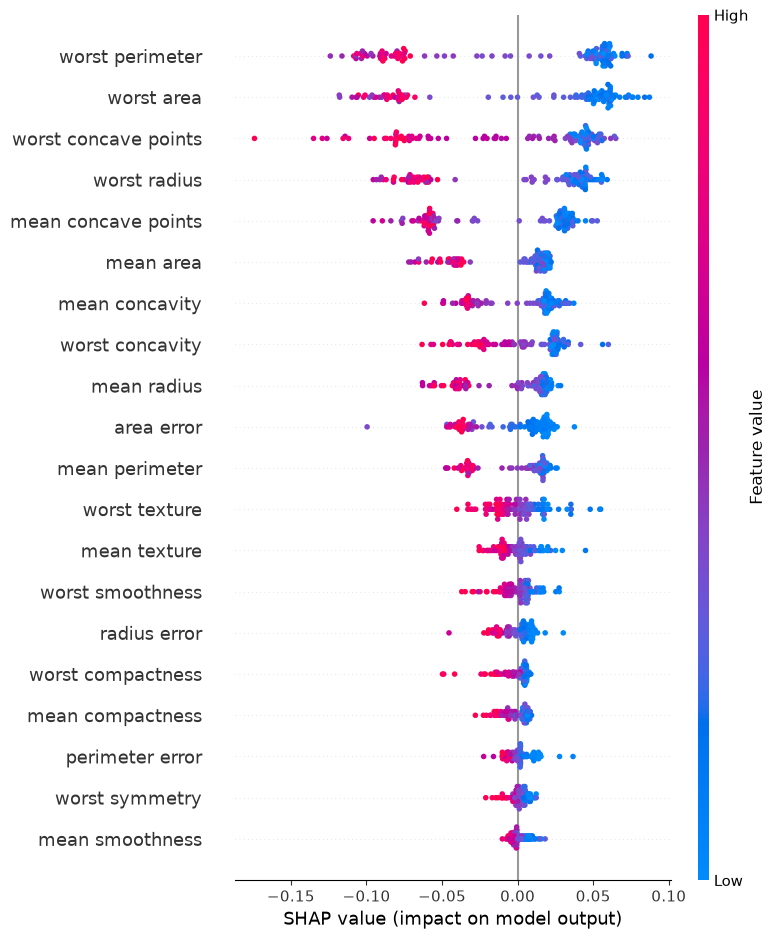

In [20]:
import shap

# Cria o "explicador" SHAP a partir do nosso Random Forest
explainer = shap.TreeExplainer(modelo_rf)
shap_values = explainer.shap_values(X_test)

# Gráfico resumo: como cada medida empurra as decisões
# (usamos a classe 1 = benigno como referência)
shap.summary_plot(shap_values[:, :, 1], X_test, show=True)

In [21]:
import joblib

# Salva o modelo campeão (Regressão Logística) e o padronizador
joblib.dump(modelo_lr, '../src/modelo_diagnostico.pkl')
joblib.dump(scaler, '../src/scaler.pkl')

print("Modelo e scaler salvos na pasta src/")
print("Arquivos criados:")
print("  - modelo_diagnostico.pkl")
print("  - scaler.pkl")

Modelo e scaler salvos na pasta src/
Arquivos criados:
  - modelo_diagnostico.pkl
  - scaler.pkl
